# Waveforms Demo (DAQ-free)

This notebook demonstrates waveform **data preparation and visualization only**.

What it does:
- Generate one period for each waveform helper in `USB6451/waveforms.py`
- Pretty-print period sample values
- Plot samples in **DAC staircase style** (`step` plot, not linear interpolation)

Plot convention in this notebook:
- x-axis: time (seconds)
- y-axis: voltage (volts)



## 1. Setup imports


In [1]:
import sys
from pathlib import Path
from pprint import pprint

import numpy as np
import matplotlib.pyplot as plt


def add_repo_to_path() -> None:
    """Ensure repository root is importable in this notebook session."""
    cwd = Path.cwd()
    if (cwd / "USB6451" / "waveforms.py").exists():
        sys.path.insert(0, str(cwd))
        return

    candidate = cwd.parent.parent
    if (candidate / "USB6451" / "waveforms.py").exists():
        sys.path.insert(0, str(candidate))
        return

    raise RuntimeError("Could not find repository root containing USB6451/waveforms.py")


add_repo_to_path()
from USB6451 import waveforms

print("Imported USB6451.waveforms")


Imported USB6451.waveforms


## 2. Global settings and plot helper


In [2]:
# User setting: sample rate used to map sample index -> time.
sample_rate = 10_000.0  # samples/second

# Print at most this many values to keep output readable.
print_limit = 64


def show_period(name: str, samples: np.ndarray, sample_rate: float, print_limit: int = 64) -> None:
    """Pretty-print one period and plot it in DAC staircase style."""
    samples = np.asarray(samples, dtype=np.float64)
    n = samples.size
    dt = 1.0 / sample_rate
    t = np.arange(n, dtype=np.float64) * dt

    # Extend one sample so final level hold is visible in step plot.
    t_step = np.append(t, t[-1] + dt)
    y_step = np.append(samples, samples[-1])

    period_time = n / sample_rate
    period_freq = sample_rate / n

    print(f"{name}")
    print(f"samples_per_period: {n}")
    print(f"sample_rate: {sample_rate:g} S/s")
    print(f"period_duration: {period_time:.9g} s")
    print(f"period_frequency: {period_freq:.9g} Hz")

    shown = samples if n <= print_limit else samples[:print_limit]
    print(f"period values (V){'' if n <= print_limit else f' first {print_limit} samples'}:")
    pprint(np.round(shown, 6).tolist())
    if n > print_limit:
        print("...")

    plt.figure(figsize=(10, 6))
    plt.step(
        t_step,
        y_step,
        where="post",
        color="darkblue",
        label="DAC output (staircase)",
    )
    plt.plot(
        t,
        samples,
        "o",
        ms=3,
        alpha=0.7,
        color="darkblue",
        label="Sample points",
    )
    plt.title(name)
    plt.xlabel("Time (s)")
    plt.ylabel("Voltage (V)")
    plt.grid(True, alpha=0.3)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()


## 3. Sine period

Sine waveform with amplitude and offset.


Sine period
samples_per_period: 64
sample_rate: 10000 S/s
period_duration: 0.0064 s
period_frequency: 156.25 Hz
period values (V):
[0.0,
 0.098017,
 0.19509,
 0.290285,
 0.382683,
 0.471397,
 0.55557,
 0.634393,
 0.707107,
 0.77301,
 0.83147,
 0.881921,
 0.92388,
 0.95694,
 0.980785,
 0.995185,
 1.0,
 0.995185,
 0.980785,
 0.95694,
 0.92388,
 0.881921,
 0.83147,
 0.77301,
 0.707107,
 0.634393,
 0.55557,
 0.471397,
 0.382683,
 0.290285,
 0.19509,
 0.098017,
 0.0,
 -0.098017,
 -0.19509,
 -0.290285,
 -0.382683,
 -0.471397,
 -0.55557,
 -0.634393,
 -0.707107,
 -0.77301,
 -0.83147,
 -0.881921,
 -0.92388,
 -0.95694,
 -0.980785,
 -0.995185,
 -1.0,
 -0.995185,
 -0.980785,
 -0.95694,
 -0.92388,
 -0.881921,
 -0.83147,
 -0.77301,
 -0.707107,
 -0.634393,
 -0.55557,
 -0.471397,
 -0.382683,
 -0.290285,
 -0.19509,
 -0.098017]


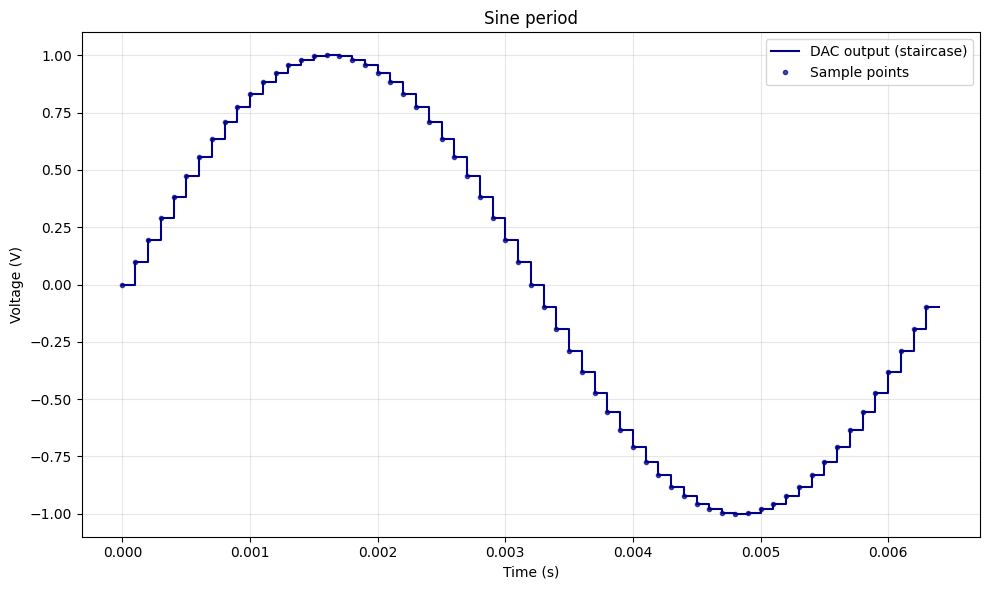

In [7]:
sine_samples = waveforms.sine_period(
    amplitude=1.0,
    offset=0.0,
    samples_per_period=64,
)
show_period("Sine period", sine_samples, sample_rate, print_limit)


## 4. Ramp period

Linear ramp from `start` toward `stop`.


Ramp period
samples_per_period: 32
sample_rate: 10000 S/s
period_duration: 0.0032 s
period_frequency: 312.5 Hz
period values (V):
[-1.0,
 -0.9375,
 -0.875,
 -0.8125,
 -0.75,
 -0.6875,
 -0.625,
 -0.5625,
 -0.5,
 -0.4375,
 -0.375,
 -0.3125,
 -0.25,
 -0.1875,
 -0.125,
 -0.0625,
 0.0,
 0.0625,
 0.125,
 0.1875,
 0.25,
 0.3125,
 0.375,
 0.4375,
 0.5,
 0.5625,
 0.625,
 0.6875,
 0.75,
 0.8125,
 0.875,
 0.9375]


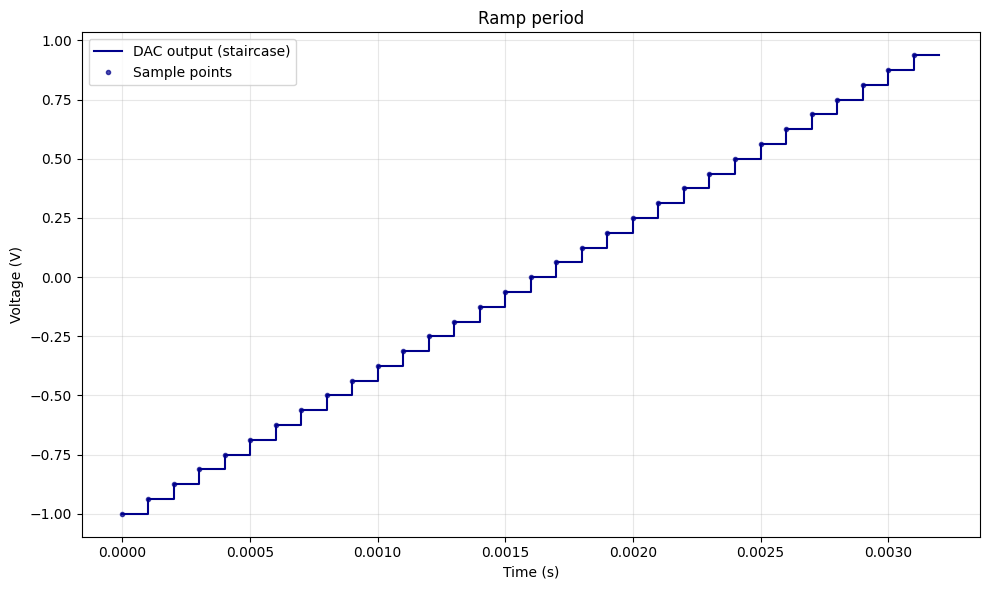

In [8]:
ramp_samples = waveforms.ramp_period(
    start=-1.0,
    stop=1.0,
    samples_per_period=32,
    include_endpoint=False,
)
show_period("Ramp period", ramp_samples, sample_rate, print_limit)


## 5. Staircase period

Discrete level sequence, each level repeated by `samples_per_level`.


Staircase period
samples_per_period: 40
sample_rate: 10000 S/s
period_duration: 0.004 s
period_frequency: 250 Hz
period values (V):
[-1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -0.5,
 -0.5,
 -0.5,
 -0.5,
 -0.5,
 -0.5,
 -0.5,
 -0.5,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.5,
 0.5,
 0.5,
 0.5,
 0.5,
 0.5,
 0.5,
 0.5,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0]


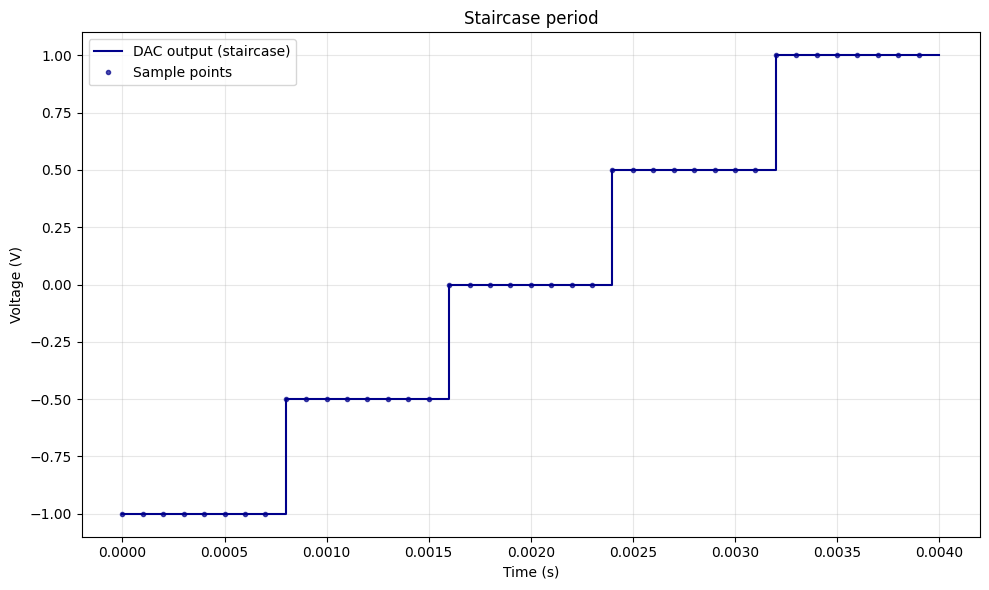

In [9]:
staircase_samples = waveforms.staircase_period(
    levels=[-1.0, -0.5, 0.0, 0.5, 1.0],
    samples_per_level=8,
)
show_period("Staircase period", staircase_samples, sample_rate, print_limit)


## 6. Triangle period

Triangle waveform with configurable symmetry.


In [ ]:
triangle_samples = waveforms.triangle_period(
    amplitude=1.0,
    offset=0.0,
    samples_per_period=80,
    symmetry=0.5,
)
show_period("Triangle period", triangle_samples, sample_rate, print_limit)


## 7. Square period

Square waveform with duty-cycle control.


Square period
samples_per_period: 40
sample_rate: 10000 S/s
period_duration: 0.004 s
period_frequency: 250 Hz
period values (V):
[1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0]


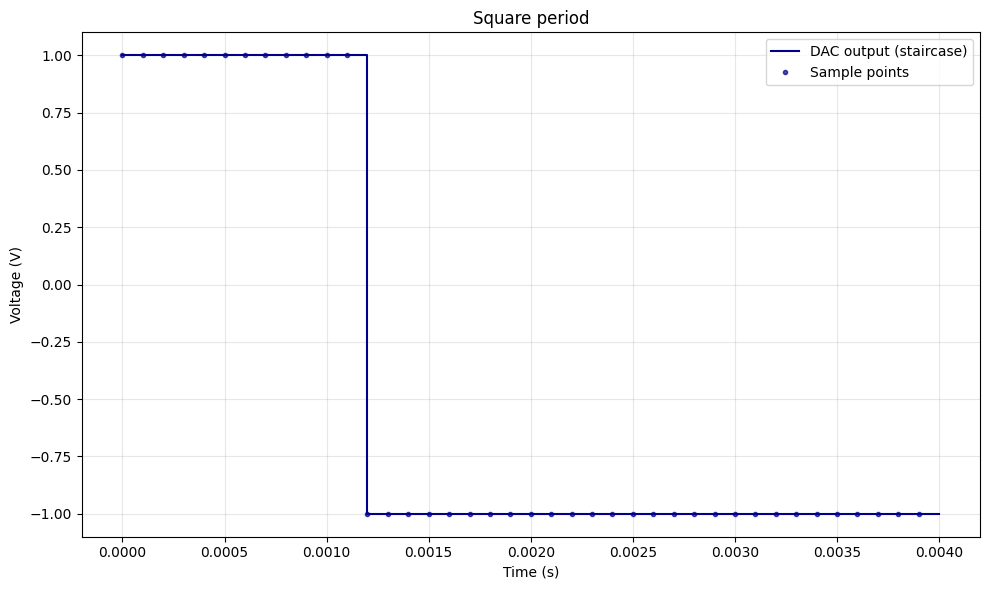

In [10]:
square_samples = waveforms.square_period(
    amplitude=1.0,
    offset=0.0,
    samples_per_period=40,
    duty=0.3,
)
show_period("Square period", square_samples, sample_rate, print_limit)


## 8. Add future waveform helpers

When a new function is added in `waveforms.py`, add one more pair of cells:
1. Markdown description
2. Code cell that calls the new helper and `show_period(...)`


## 9. Interactive waveform explorer

Use this section to explore all waveform helpers with live controls.

Notes:
- Run setup/helper cells first (sections 1 and 2).
- Requires `ipywidgets` in your Jupyter environment.


In [ ]:
try:
    import ipywidgets as widgets
    from IPython.display import display
except Exception as exc:
    print('ipywidgets is not available in this environment.')
    print(exc)
else:
    waveform_kind = widgets.Dropdown(
        options=['sine', 'ramp', 'staircase', 'triangle', 'square'],
        value='sine',
        description='waveform',
    )

    sample_rate_w = widgets.FloatText(value=sample_rate, description='sample_rate')
    samples_per_period_w = widgets.IntText(value=64, description='samples_per_period')
    print_limit_w = widgets.IntText(value=print_limit, description='print_limit')

    amplitude_w = widgets.FloatText(value=1.0, description='amplitude')
    offset_w = widgets.FloatText(value=0.0, description='offset')

    ramp_start_w = widgets.FloatText(value=-1.0, description='ramp_start')
    ramp_stop_w = widgets.FloatText(value=1.0, description='ramp_stop')
    ramp_endpoint_w = widgets.Checkbox(value=False, description='ramp_endpoint')

    levels_w = widgets.Text(value='-1,-0.5,0,0.5,1', description='levels')
    samples_per_level_w = widgets.IntText(value=8, description='samples_per_level')

    symmetry_w = widgets.FloatText(value=0.5, description='symmetry')
    duty_w = widgets.FloatText(value=0.3, description='duty')

    run_btn = widgets.Button(description='Generate and plot', button_style='success')
    out = widgets.Output()

    def _parse_levels(text: str):
        parts = [p.strip() for p in text.split(',') if p.strip() != '']
        if not parts:
            raise ValueError('levels must contain at least one numeric value.')
        return [float(p) for p in parts]

    def _build_samples():
        kind = waveform_kind.value
        if kind == 'sine':
            return waveforms.sine_period(
                amplitude=amplitude_w.value,
                offset=offset_w.value,
                samples_per_period=samples_per_period_w.value,
            )
        if kind == 'ramp':
            return waveforms.ramp_period(
                start=ramp_start_w.value,
                stop=ramp_stop_w.value,
                samples_per_period=samples_per_period_w.value,
                include_endpoint=ramp_endpoint_w.value,
            )
        if kind == 'staircase':
            return waveforms.staircase_period(
                levels=_parse_levels(levels_w.value),
                samples_per_level=samples_per_level_w.value,
            )
        if kind == 'triangle':
            return waveforms.triangle_period(
                amplitude=amplitude_w.value,
                offset=offset_w.value,
                samples_per_period=samples_per_period_w.value,
                symmetry=symmetry_w.value,
            )
        if kind == 'square':
            return waveforms.square_period(
                amplitude=amplitude_w.value,
                offset=offset_w.value,
                samples_per_period=samples_per_period_w.value,
                duty=duty_w.value,
            )
        raise ValueError(f'Unsupported waveform: {kind}')

    def _run(_=None):
        with out:
            out.clear_output()
            try:
                samples = _build_samples()
                show_period(
                    name=f'Interactive {waveform_kind.value} period',
                    samples=samples,
                    sample_rate=sample_rate_w.value,
                    print_limit=print_limit_w.value,
                )
            except Exception as exc:
                print('Error:')
                print(exc)

    run_btn.on_click(_run)

    controls = widgets.VBox([
        waveform_kind,
        sample_rate_w,
        samples_per_period_w,
        print_limit_w,
        amplitude_w,
        offset_w,
        ramp_start_w,
        ramp_stop_w,
        ramp_endpoint_w,
        levels_w,
        samples_per_level_w,
        symmetry_w,
        duty_w,
        run_btn,
    ])

    display(controls, out)
    _run()
